<a href="https://colab.research.google.com/github/Zeeba1705/atml_PA0/blob/main/Task2_ViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 2: Vision Transformers

###2.1: Using a Pre-trained ViT

In [17]:
import torch
import matplotlib.pyplot as plt

from PIL import Image
from transformers import ViTImageProcessor, ViTForImageClassification

device= torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [18]:
#decided to use huggingface ViT-Base/16

model_name = "google/vit-base-patch16-224"

#to prep test images in the same way images used to train this model were prepped
proc= ViTImageProcessor.from_pretrained(model_name)

model= ViTForImageClassification.from_pretrained(model_name)

model= model.to(device)
model.eval()

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out

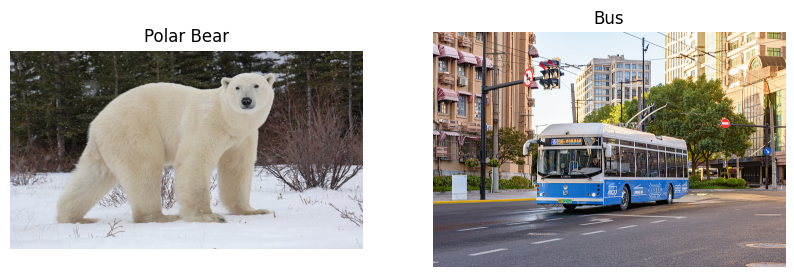

In [5]:
bear_img= Image.open("polar_bear.avif").convert("RGB")
bus_img= Image.open("bus.jpg").convert("RGB")

images = [bear_img, bus_img]

fig,axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(bear_img)
axes[0].set_title("Polar Bear")
axes[0].axis("off")

axes[1].imshow(bus_img)
axes[1].set_title("Bus")
axes[1].axis("off")

plt.show()

In [6]:
inputs= proc(images=images, return_tensors="pt")

inputs= {key: value.to(device) for key,value in inputs.items()}

In [6]:
print(inputs["pixel_values"].shape)

torch.Size([2, 3, 224, 224])


In [7]:
with torch.no_grad():
  outs=model(**inputs)

logits=outs.logits



In [8]:
preds=logits.argmax(dim=1)

for i, predicted in enumerate(preds):
    label= model.config.id2label[predicted.item()]
    print(f"Image {i + 1}: {label}")

Image 1: ice bear, polar bear, Ursus Maritimus, Thalarctos maritimus
Image 2: trolleybus, trolley coach, trackless trolley


Model predicted polar bear for the first image and trolleybus for the second, successful!



---



###Task 2.2: Visualizing Patch Attention

In [10]:
model = ViTForImageClassification.from_pretrained(
    model_name,
    attn_implementation="eager"
)

model = model.to(device)
model.eval()

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out

In [11]:
with torch.no_grad():
    outputs= model(**inputs, output_attentions=True)

attentions= outputs.attentions

print(len(attentions))

#final transformer layer, attention matrix
print(attentions[-1].shape)

12
torch.Size([2, 12, 197, 197])




*   batch_size = 2
*   no. of attention heads= 12
* seq_len = 197 (1 CLS token + 196 patch tokens)
   





In [13]:
final_atten= attentions[-1]

cls_atten = final_atten[:, :, 0, 1:]

In [16]:
#computing the avg over attention heads and then reshaping to 14x14 attention maps

cls_atten_mean= cls_atten.mean(dim=1)

print(cls_atten_mean.shape)

attention_maps= cls_atten_mean.reshape(2, 14, 14)

print(attention_maps.shape)

torch.Size([2, 196])
torch.Size([2, 14, 14])


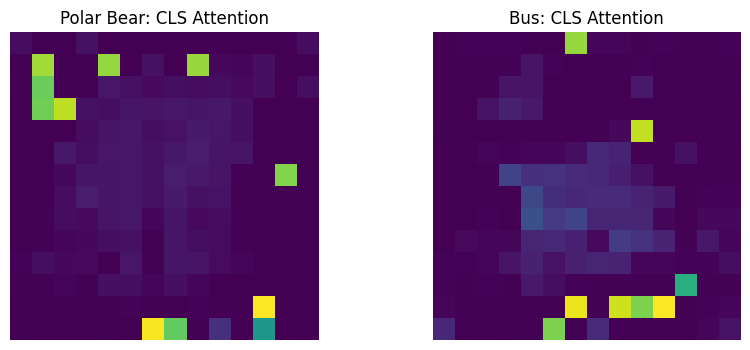

In [17]:
fig, axes= plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(attention_maps[0].cpu())
axes[0].set_title("Polar Bear: CLS Attention")
axes[0].axis("off")

axes[1].imshow(attention_maps[1].cpu())
axes[1].set_title("Bus: CLS Attention")
axes[1].axis("off")

plt.show()

In [19]:
#need to go from 14x14 to 224x224 as ViT input is 224x224

import torch.nn.functional as F

attention_upsampled= F.interpolate(attention_maps.unsqueeze(1), size=(224, 224),
    mode="bilinear", align_corners=False)

attention_upsampled= attention_upsampled.squeeze(1)

print(attention_upsampled.shape)

torch.Size([2, 224, 224])


In [20]:
attention_norm = []

for i in range(attention_upsampled.shape[0]):
    attn= attention_upsampled[i]
    attn= attn - attn.min()
    attn= attn / attn.max()
    attention_norm.append(attn)

attention_norm = torch.stack(attention_norm)

print(attention_norm.shape)

torch.Size([2, 224, 224])


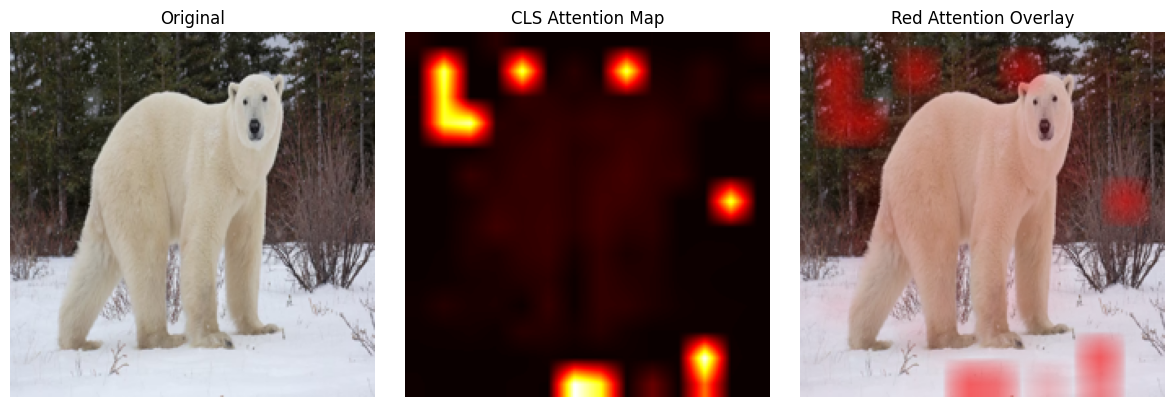

In [68]:
import numpy as np
import matplotlib.pyplot as plt

bear_resized = bear_img.resize((224, 224))
attn = attention_norm[0].cpu().numpy()

red_overlay = np.zeros((224, 224, 4))
red_overlay[..., 0] = 1.0
red_overlay[..., 1] = 0.0
red_overlay[..., 2] = 0.0
red_overlay[..., 3] = np.sqrt(attn) * 0.6

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(bear_resized)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(attn, cmap="hot")
axes[1].set_title("CLS Attention Map")
axes[1].axis("off")

axes[2].imshow(bear_resized)
axes[2].imshow(red_overlay)
axes[2].set_title("Red Attention Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

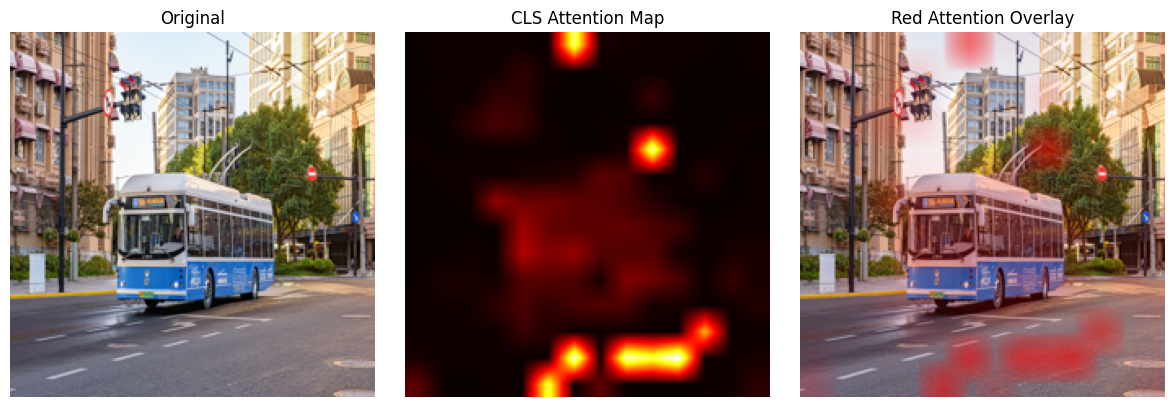

In [64]:
import numpy as np
import matplotlib.pyplot as plt

bus_resized = bus_img.resize((224, 224))
attn= attention_norm[1].cpu().numpy()

red_overlay = np.zeros((224, 224, 4))
red_overlay[..., 0] = 1.0
red_overlay[..., 1] = 0.0
red_overlay[..., 2] = 0.0
red_overlay[..., 3] = np.sqrt(attn) * 0.6

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(bus_resized)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(attn, cmap="hot")
axes[1].set_title("CLS Attention Map")
axes[1].axis("off")

axes[2].imshow(bus_resized)
axes[2].imshow(red_overlay)
axes[2].set_title("Red Attention Overlay")
axes[2].axis("off")

plt.tight_layout()

###1.3: Testing attention maps of multiple heads

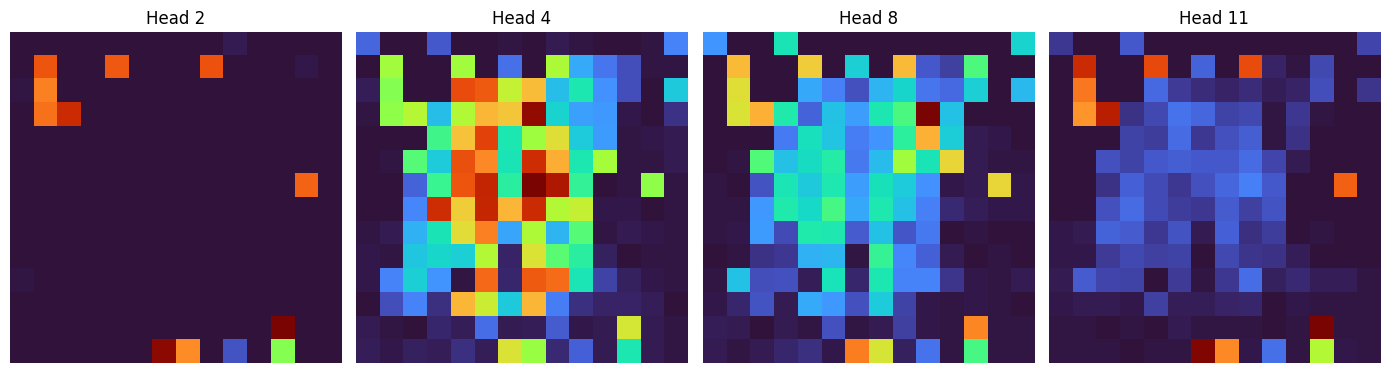

In [45]:
image_idx= 0   #0= polar bear
head_indices= [2, 4, 8, 11]

final_attention= attentions[-1]

fig, axes = plt.subplots(1, len(head_indices), figsize=(14, 4))

for i, head_idx in enumerate(head_indices):
    head_map= final_attention[image_idx, head_idx, 0, 1:]
    head_map= head_map.reshape(14, 14).cpu()

    axes[i].imshow(head_map, cmap="turbo")
    axes[i].set_title(f"Head {head_idx}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

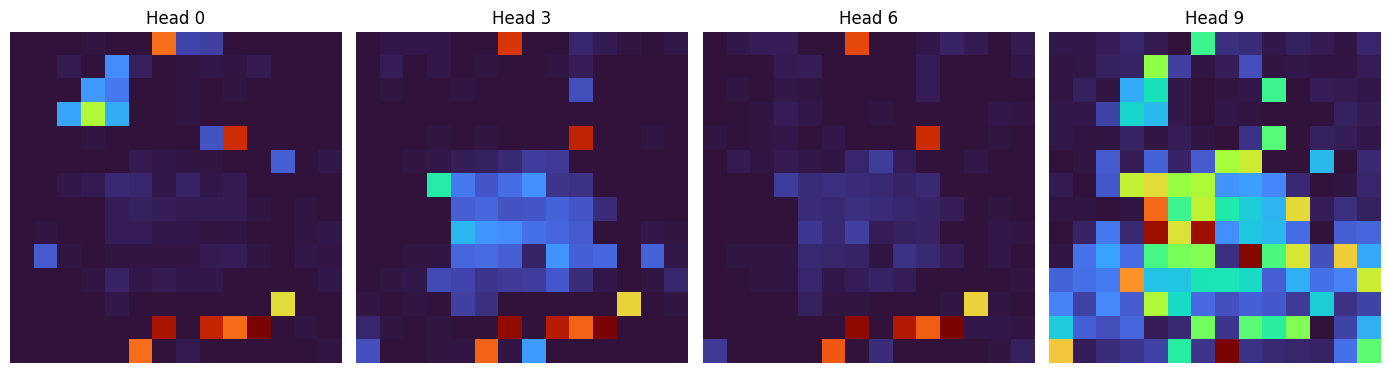

In [54]:
image_idx= 1   #1 = bus
head_indices= [0, 3, 6, 9]

final_attention= attentions[-1]

fig, axes = plt.subplots(1, len(head_indices), figsize=(14, 4))

for i, head_idx in enumerate(head_indices):
    head_map = final_attention[image_idx, head_idx, 0, 1:]
    head_map = head_map.reshape(14, 14).cpu()

    axes[i].imshow(head_map, cmap="turbo")
    axes[i].set_title(f"Head {head_idx}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

###2.4: Patch Masking Experiment

In [2]:
def mask_patches(pixel_values, mask_frac=0.25, mode="random"):
    masked= pixel_values.clone()

    patch_size= 16
    grid_size= 14
    total_patches= grid_size * grid_size #14x14=196
    num_masked= int(total_patches * mask_frac)

    if mode== "random": #first tryig out the random patch masking
        patch_indices= torch.randperm(total_patches)[:num_masked]

        for idx in patch_indices:
            row= idx // grid_size
            col= idx % grid_size

            y1= row * patch_size
            y2= y1 + patch_size
            x1= col * patch_size
            x2= x1 + patch_size

            masked[:, :, y1:y2, x1:x2] = 0

    elif mode == "center":
        side= int(num_masked ** 0.5)

        start = (grid_size - side) // 2
        end = start + side

        y1= start * patch_size
        y2= end * patch_size
        x1= start * patch_size
        x2= end * patch_size

        masked[:, :, y1:y2, x1:x2] = 0

    return masked

In [7]:
rand_masked=mask_patches(pixel_values=inputs["pixel_values"], mask_frac=0.25, mode="random")

center_masked= mask_patches(pixel_values=inputs["pixel_values"],mask_frac=0.25, mode="center")

with torch.no_grad():
    og_outputs= model(pixel_values=inputs["pixel_values"])
    rand_outputs = model(pixel_values=rand_masked)
    center_outputs = model(pixel_values=center_masked)

og_probs = torch.softmax(og_outputs.logits, dim=1)
random_probs = torch.softmax(rand_outputs.logits, dim=1)
center_probs = torch.softmax(center_outputs.logits, dim=1)


In [8]:
conditions = {"Original": og_probs, "Random 25% Mask": random_probs,"Center 25% Mask": center_probs}

for image_idx in range(2):
    print(f"\nImage {image_idx + 1}")

    for name, probs in conditions.items():
        predicted_id = probs[image_idx].argmax().item()
        confidence = probs[image_idx, predicted_id].item()

        label= model.config.id2label[predicted_id]

        print(
            f"{name}: {label} "
            f"({confidence:.2%})"
        )


Image 1
Original: ice bear, polar bear, Ursus Maritimus, Thalarctos maritimus (99.91%)
Random 25% Mask: ice bear, polar bear, Ursus Maritimus, Thalarctos maritimus (99.89%)
Center 25% Mask: ice bear, polar bear, Ursus Maritimus, Thalarctos maritimus (99.32%)

Image 2
Original: trolleybus, trolley coach, trackless trolley (98.82%)
Random 25% Mask: trolleybus, trolley coach, trackless trolley (72.82%)
Center 25% Mask: traffic light, traffic signal, stoplight (57.44%)


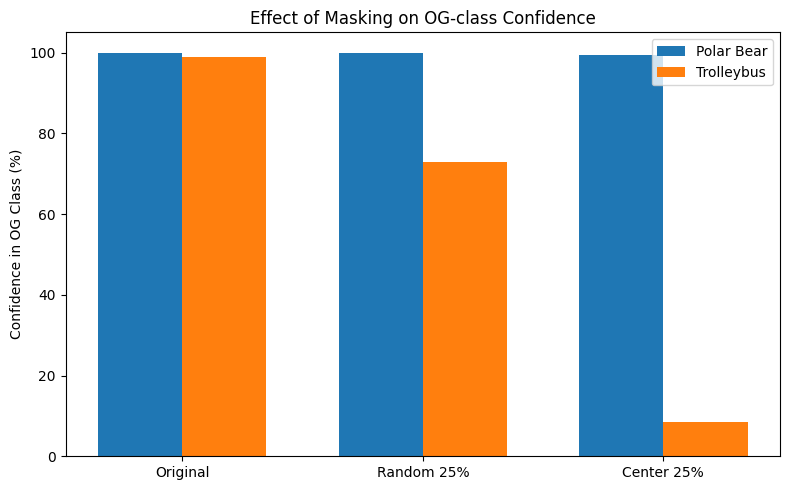

In [10]:
import numpy as np
import matplotlib.pyplot as plt

conditions= ["Original", "Random 25%", "Center 25%"]

original_class_ids = og_probs.argmax(dim=1)

bear_class_id = original_class_ids[0].item()
bus_class_id = original_class_ids[1].item()

bear_confidence = [
    og_probs[0, bear_class_id].item() * 100,
    random_probs[0, bear_class_id].item() * 100,
    center_probs[0, bear_class_id].item() * 100
]

bus_confidence = [
    og_probs[1, bus_class_id].item() * 100,
    random_probs[1, bus_class_id].item() * 100,
    center_probs[1, bus_class_id].item() * 100
]

x = np.arange(len(conditions))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width/2, bear_confidence, width, label="Polar Bear")
ax.bar(x + width/2, bus_confidence, width, label="Trolleybus")

ax.set_ylabel("Confidence in OG Class (%)")
ax.set_title("Effect of Masking on OG-class Confidence")

ax.set_xticks(x)
ax.set_xticklabels(conditions)

ax.set_ylim(0, 105)
ax.legend()

plt.tight_layout()
plt.show()

###2.5: CLS Token vs. Mean-Pooled Patch Tokens:

In [14]:
#using CIFAR10 dataset

from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader, Subset

train_dataset = CIFAR10(root="./data", train=True, download=True)

test_dataset = CIFAR10(root="./data", train=False,download=True)

train_subset= Subset(train_dataset, range(5000))
test_subset= Subset(test_dataset, range(1000))

print(len(train_subset))
print(len(test_subset))

5000
1000


In [21]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    images= [item[0] for item in batch]
    labels= torch.tensor([item[1] for item in batch])

    processed= proc(images=images,return_tensors="pt")

    return processed["pixel_values"], labels


train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_subset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

In [23]:
def extract_features(dataloader):
    cls_features= []
    mean_features= []
    all_labels= []

    model.eval()

    with torch.no_grad():
        for pixel_values, labels in dataloader:
            pixel_values= pixel_values.to(device)

            outputs= model.vit(pixel_values=pixel_values)

            hidden_states = outputs.last_hidden_state

            cls_batch = hidden_states[:, 0, :]

            patch_tokens = hidden_states[:, 1:, :]

            mean_batch = patch_tokens.mean(dim=1)

            cls_features.append(cls_batch.cpu())
            mean_features.append(mean_batch.cpu())
            all_labels.append(labels)

    cls_features= torch.cat(cls_features)
    mean_features = torch.cat(mean_features)
    all_labels = torch.cat(all_labels)

    return cls_features, mean_features, all_labels

In [24]:
train_cls, train_mean, train_labels = extract_features(train_loader)

test_cls, test_mean, test_labels = extract_features(test_loader)

In [25]:
print("Train CLS:", train_cls.shape)
print("Train Mean:", train_mean.shape)
print("Train Labels:", train_labels.shape)

print("Test CLS:", test_cls.shape)
print("Test Mean:", test_mean.shape)
print("Test Labels:", test_labels.shape)

Train CLS: torch.Size([5000, 768])
Train Mean: torch.Size([5000, 768])
Train Labels: torch.Size([5000])
Test CLS: torch.Size([1000, 768])
Test Mean: torch.Size([1000, 768])
Test Labels: torch.Size([1000])


In [26]:
import torch.nn as nn

cls_probe = nn.Linear(768, 10).to(device)
mean_probe = nn.Linear(768, 10).to(device)

In [28]:
def train_probe(probe, features, labels, epochs=20, lr=0.001):
    features = features.to(device)
    labels = labels.to(device)

    crit= nn.CrossEntropyLoss()
    optim= torch.optim.Adam(probe.parameters(), lr=lr)

    for epoch in range(epochs):
        probe.train()
        optim.zero_grad()

        outputs= probe(features)
        loss= crit(outputs, labels)

        loss.backward()
        optim.step()

        if (epoch + 1) % 5 == 0:
            print(
                f"Epoch {epoch + 1}/{epochs}, "
                f"Loss: {loss.item():.4f}"
            )

print("CLS probe")
train_probe(cls_probe,train_cls,train_labels)

print("\nMean-pooled probe")
train_probe(mean_probe,train_mean,train_labels)

CLS probe
Epoch 5/20, Loss: 1.4868
Epoch 10/20, Loss: 0.7278
Epoch 15/20, Loss: 0.3983
Epoch 20/20, Loss: 0.2664

Mean-pooled probe
Epoch 5/20, Loss: 1.5494
Epoch 10/20, Loss: 0.9050
Epoch 15/20, Loss: 0.5519
Epoch 20/20, Loss: 0.3775


In [29]:
def eval_probe(probe, features, labels):
    probe.eval()

    features= features.to(device)
    labels= labels.to(device)

    with torch.no_grad():
        outputs= probe(features)
        preds= outputs.argmax(dim=1)

    acc= (preds== labels).float().mean().item()

    return acc

cls_acc=eval_probe(cls_probe, test_cls, test_labels)
mean_acc= eval_probe(mean_probe, test_mean, test_labels)

print(f"CLS token accuracy: {cls_acc * 100:.2f}%")
print(f"Mean-pooled accuracy: {mean_acc* 100:.2f}%")

CLS token accuracy: 94.60%
Mean-pooled accuracy: 94.80%


Similar performance for CLS and mean patch pooling.

In [30]:
train_cls_acc= eval_probe(cls_probe, train_cls,train_labels)

train_mean_acc = eval_probe(mean_probe,train_mean,train_labels)

print(f"CLS train accuracy: {train_cls_acc * 100:.2f}%")
print(f"Mean-pooled train accuracy: {train_mean_acc* 100:.2f}%")

CLS train accuracy: 95.56%
Mean-pooled train accuracy: 95.30%


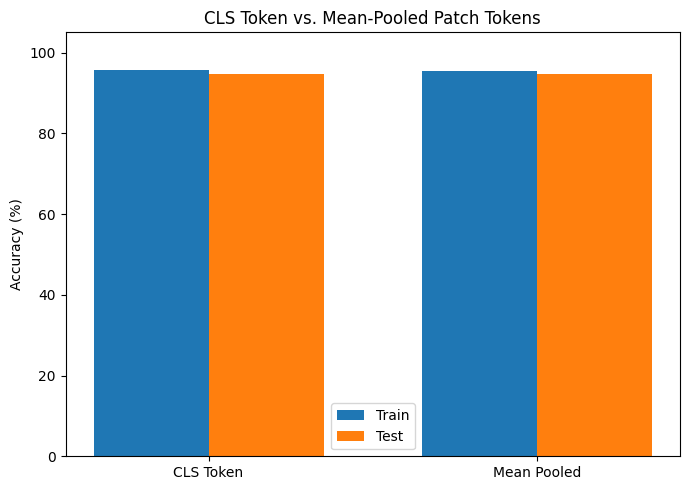

In [31]:
import matplotlib.pyplot as plt
import numpy as np

methods = ["CLS Token", "Mean Pooled"]

train_accuracies = [train_cls_acc * 100,train_mean_acc* 100]

test_accuracies = [cls_acc* 100,mean_acc* 100]

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))

train_bars = ax.bar(
    x - width/2,
    train_accuracies,
    width,
    label="Train"
)

test_bars = ax.bar(
    x + width/2,
    test_accuracies,
    width,
    label="Test"
)

ax.set_ylabel("Accuracy (%)")
ax.set_title("CLS Token vs. Mean-Pooled Patch Tokens")
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylim(0, 105)
ax.legend()

plt.tight_layout()
plt.show()